# **Limpieza de los datos del pergamino del oráculo**

Librerias necesarias para la limpieza de los datos

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

**Preparación y carga**

Lo primero es identificar los simbolos que significan vacios en el pergamino antes de importar el csv mágico. Creamos dos variables 'archivo_entrada' y 'archivo_salida' para guardar el nombre del pergamino corrupto y el pergamino limpio

In [2]:
archivo_entrada = 'bosque_maldito_belatz.csv'
archivo_salida = 'bosque_maldito_limpio.csv'
valores_nulos = ['?', '??', 'Na', 'nan', '--', ' ', '']

* **na_values**: No todos los nulos vienen como celdas vacías. Algunos son ruidos del sistema (como ?? o --). Con esto, le decimos a pandas que transforme automáticamente esos caracteres en NaN (valores nulos reales).

Cargamos el pergamino.

In [3]:
df = pd.read_csv(archivo_entrada, na_values=valores_nulos)

In [4]:
df.head(5)

,id_incidencia,mazmorra,dificultad,olenthero_en_equipo,olenthero_vida,olenthero_mana,olenthero_fisico,olenthero_agilidad,thorgin_en_equipo,thorgin_vida,...,lamyreth_vida,lamyreth_mana,lamyreth_fisico,lamyreth_agilidad,sugarth_en_equipo,sugarth_vida,sugarth_mana,sugarth_fisico,sugarth_agilidad,exito
0,1.0,bosque_maldito_belatz,3.0,1.0,5.0,4.0,9.0,NaN,1.0,1.0,...,3.0,5.0,5.0,7.0,0.0,0.0,0.0,0.0,0.0,0
1,NaN,bosque_maldito_belatz,1.0,1.0,8.0,2.0,9.0,1.0,1.0,3.0,...,0.0,0.0,0.0,0.0,1.0,4.0,4.0,9.0,3.0,0
2,3.0,bosque_maldito_belatz,1.0,1.0,6.0,3.0,9.0,2.0,1.0,-1.0,...,0.0,0.0,0.0,0.0,1.0,4.0,4.0,8.0,4.0,1
3,4.0,bosque_maldito_belatz,2.0,1.0,5.0,NaN,9.0,2.0,1.0,-1.0,...,0.0,0.0,0.0,0.0,1.0,5.0,4.0,8.0,3.0,0
4,NaN,bosque_maldito_belatz,2.0,1.0,5.0,3.0,11.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,NaN,7.0,4.0,7.0,2.0,0


**Limpieza e integridad**

Limpieza de estructura básica. (El target es obligatorio)

In [5]:
df = df.drop_duplicates()
df = df.dropna(subset=['exito'])

* **drop_duplicates()**: Elimina filas idénticas. Tener dos veces la misma es redundante y sesgaria el entrenamiento del modelo.

* **dropna(subset=['exito'])**: El exito es nuestra variable objetivo (target). Si no sabemos si la misión fue un éxito o un fracaso, esa fila no nos sirve para enseñar al modelo a predecir.

In [6]:
df = df.drop(columns=['id_incidencia'], errors='ignore')

* **drop(columns=['id_incidencia'])**: Eliminamos el ID. En Machine Learning, los IDs son peligrosos porque el modelo puede creer que el número de ID causa el éxito (por ejemplo, pensar que los IDs más altos ganan más), lo cual es falso.

* **index=False**: Al guardar el CSV, evitamos que pandas cree una columna extra de números al principio del archivo.

**Normalización de dificultad**

In [7]:
df['dificultad'] = pd.to_numeric(df['dificultad'], errors='coerce')
df['dificultad'] = df['dificultad'].fillna(df['dificultad'].median())
df['dificultad'] = df['dificultad'].abs()

* **to_numeric(..., errors='coerce')**: Intenta convertir la columna a números. Si encuentra texto que no puede convertir, lo transforma en NaN.

* **median()**: Usamos la mediana para rellenar huecos porque, a diferencia de la media, no se ve afectada por valores extremadamente altos o bajos (outliers).

* **abs()**: Corrige errores de signo. No existe una dificultad negativa en el Bosque Maldito.

**Detección de Outliers (Valores Atípicos)**

Visualización de valores atipicos en el pergamino

Para que seaborn pueda dibujar múltiples cajas automáticamente, necesitamos pasar los datos de un formato "ancho" (muchas columnas: olenthero_vida, thorgin_vida...) a un formato "largo" (una sola columna que diga el tipo de dato).

In [8]:
stats_types = ['vida', 'mana', 'fisico', 'agilidad']
cols_stats = [c for c in df.columns if any(c.endswith(f"_{s}") for s in stats_types)]

* **stats_types**: Definimos una lista con las 4 palabras clave que buscamos (vida, mana, fisico, agilidad).

* **cols_stats**: Usamos una lista de comprensión para filtrar y guardar solo los nombres de las columnas del pergamino (dataframe) que terminan con esos sufijos.

In [9]:
df_long = df[cols_stats].melt(var_name='columna_original', value_name='Valor')

Toma todas las columnas de estadísticas y las apila en una sola columna llamada Valor.

Crea otra columna llamada "columna_original" que guarda de dónde vino el dato. ej: olenthero_vida.

In [10]:
df_long[['Heroe', 'Estadistica']] = df_long['columna_original'].str.rsplit('_', n=1, expand=True)

Separamos el string "heroe_stat" en dos columnas: "Heroe" y "Estadistica",usamos rsplit para separar solo por el último guion bajo

Creación del gráfico

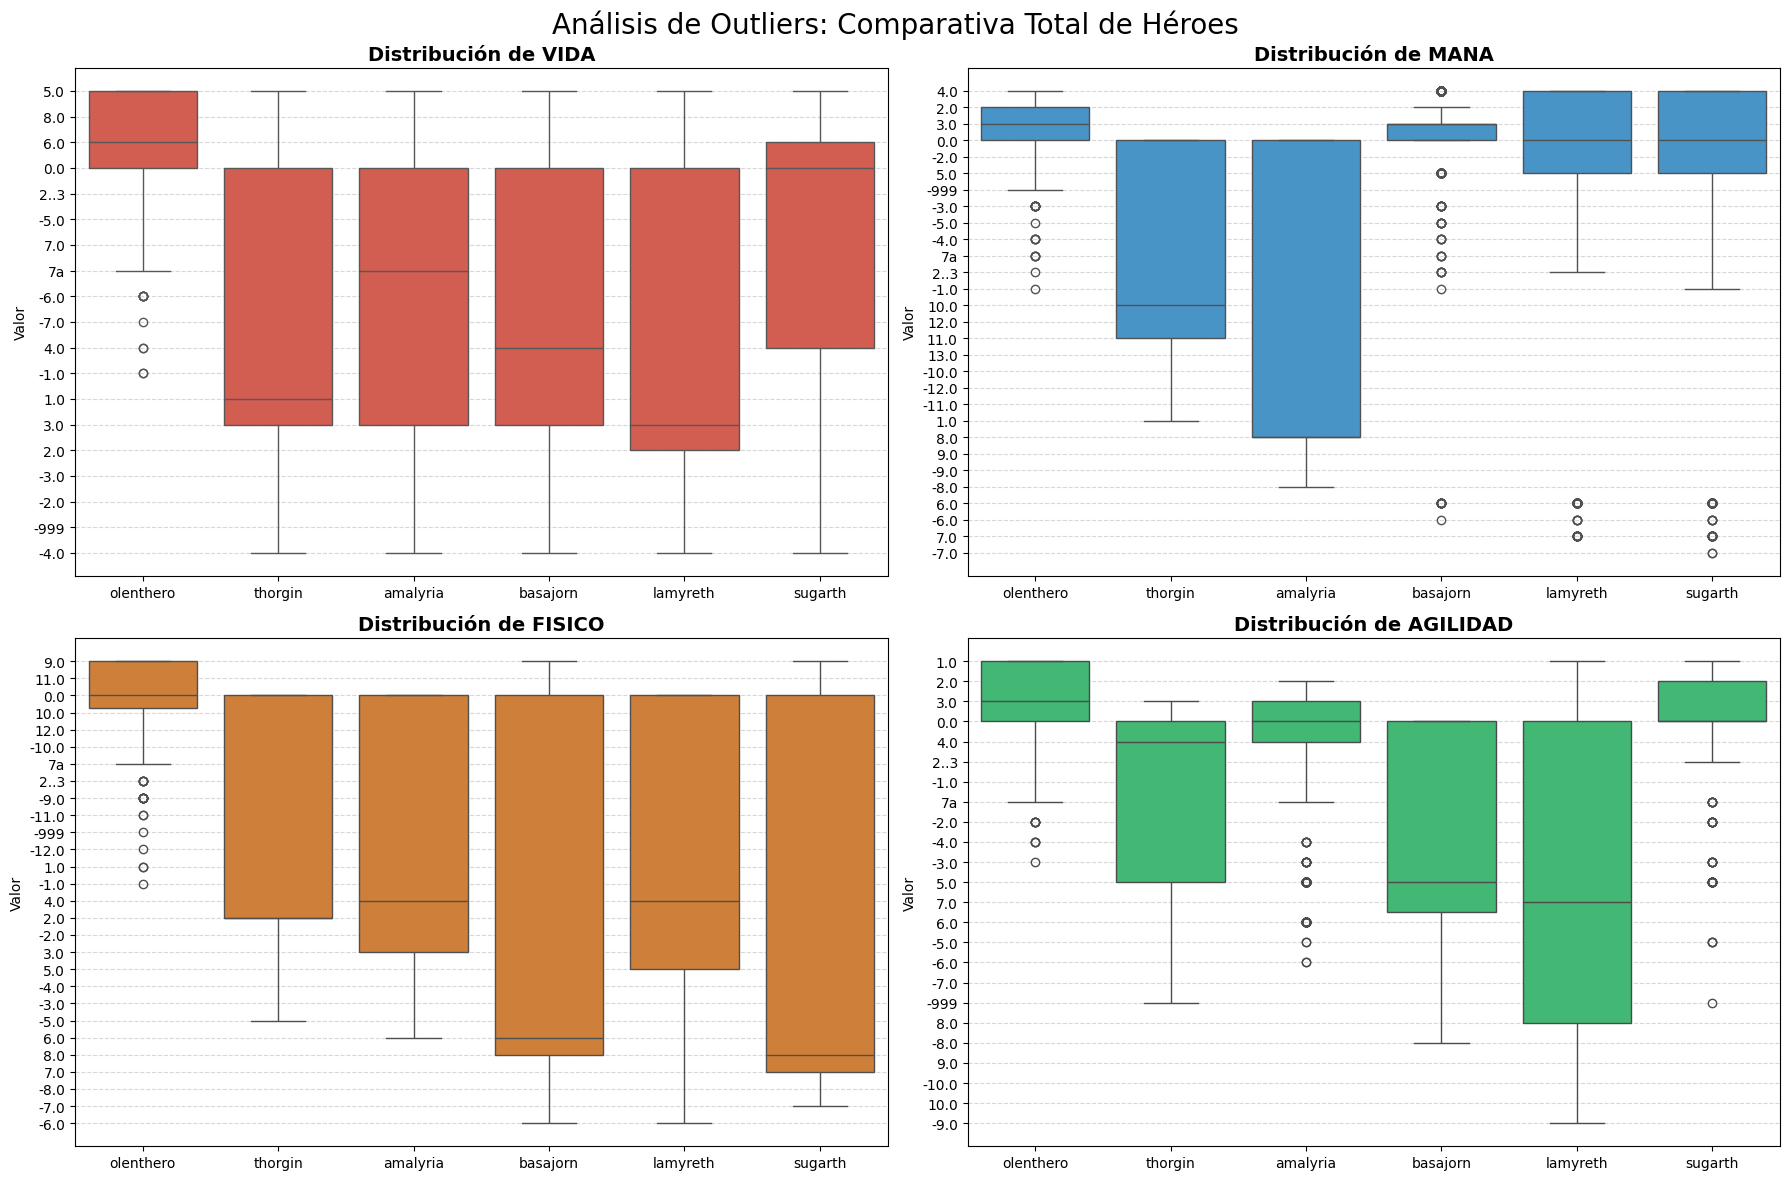

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Análisis de Outliers: Comparativa Total de Héroes', fontsize=20)
palette_map = {'vida': '#e74c3c', 'mana': '#3498db', 'fisico': '#e67e22', 'agilidad': '#2ecc71'}

for i, stat in enumerate(stats_types):
    row, col = i // 2, i % 2
    ax = axes[row, col]

    subset = df_long[df_long['Estadistica'] == stat]

    sns.boxplot(data=subset, x='Heroe', y='Valor', ax=ax, color=palette_map[stat])

    ax.set_title(f'Distribución de {stat.upper()}', fontsize=14, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Valor')
    ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

* **plt.subplots(2, 2, ...)**: Crea una figura vacía preparada para albergar 4 gráficos organizados en 2 filas y 2 columnas.

* **palette_map**: Diccionario manual para asignar un color específico a cada estadística.

Búcle para crear los cuatro gráficos

**La consistencia de roles**:

En el gráfico de VIDA (Rojo), héroes como Olenthero (tanque) deberían tener las cajas más altas. Comopodemos ver la caja de Olenthero es muy baja, eso significa uqe hay muchos outliers

En el de MANA (Azul), Thorgin (mago) debería dominar.

Los Outliers:

Los puntos negros fuera de las cajas: como que limpiamos los datos con la mediana y valores fijos, es probable que veamos:

* Muchos puntos en el cero: Si un héroe no fue a la misión (valor 0), aparece como outlier en la parte inferior.

In [12]:
def eliminar_outliers_iqr(df, columnas_a_limpiar):

    df_limpio = df.copy()
    indices_outliers = set()

    print(f"Filas antes de limpiar outliers: {len(df_limpio)}")

    for col in columnas_a_limpiar:
        df_limpio[col] = pd.to_numeric(df_limpio[col], errors='coerce')

        Q1 = df_limpio[col].quantile(0.25)
        Q3 = df_limpio[col].quantile(0.75)
        IQR = Q3 - Q1

        limite_inferior = Q1 - 1.5 * IQR
        limite_superior = Q3 + 1.5 * IQR

        outliers_columna = df_limpio[
            (df_limpio[col] < limite_inferior) |
            (df_limpio[col] > limite_superior)
        ].index

        if len(outliers_columna) > 0:
            val_max = df_limpio.loc[outliers_columna, col].max()
            if val_max > 20:
                print(f"Detectado valor extremo en '{col}': {val_max}!")

        indices_outliers.update(outliers_columna)

    df_limpio = df_limpio.drop(indices_outliers)

    print(f"Filas eliminadas: {len(indices_outliers)}")
    print(f"Filas restantes: {len(df_limpio)}")
    return df_limpio


cols_stats = [c for c in df.columns if ('vida' in c or 'mana' in c or 'fisico' in c or 'agilidad' in c)]

df = eliminar_outliers_iqr(df, cols_stats)

Filas antes de limpiar outliers: 856
Filas eliminadas: 21
Filas restantes: 835


La función "eliminar_outliers_iqr" implementa el Método del Rango Intercuartilico (IQR), es la técnica estandar estadística para detectar anomalías sin depender de que los datos sigan una distribución normal perfecta.

* **df_limpio = df.copy():** Creamos una copia independiente del dataset original. Lo hemos realizado para no modificar el df original por accidente si algo sale mal dentro de la función.

E·l código recorre una a una las columnas numéricas que le indicamos (vida, maná, físico y agilidad)

Se aplica el Método del Rango Intercuartilico.



¿Por qué es vital tratar los outliers?

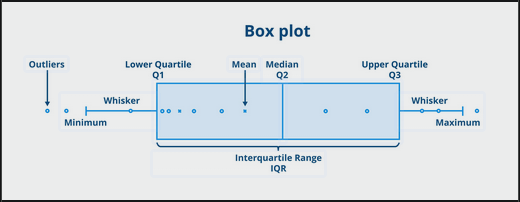

Protege la Media (El promedio):

Imaginemos que tenemos 5 héroes con fuerza: [2, 3, 2, 4, 1000].

El promedio es 202. Esto es mentira, la mayoría tiene fuerza 2 o 3. El modelo pensará que el héroe promedio es un semidiós solo por culpa de un dato erróneo (el 1000). Al quitar el outlier, el promedio vuelve a ser real (2.7).

Mejora el Aprendizaje del Modelo:

Muchos algoritmos (como la Regresión Lineal o las Redes Neuronales) intentan minimizar el error general. Si hay un punto muy lejos (un outlier), el modelo se estirará y deformará para intentar abarcar ese punto, perjudicando su capacidad de predecir los casos normales.

Normalización Correcta:

Más adelante, escalaremos los datos (ponerlos entre 0 y 1).

Si tenemos un outlier de 1000 y el resto son 5, al escalar, el 1000 será un 1.0 y todos los datos normales quedarán aplastados en 0.005. Esto hace que el modelo no pueda ver las diferencias sutiles entre los datos reales.

Ruido vs. Realidad:

En nuestro caso del "Bosque Maldito", un outlier suele significar corrupción de datos (un error de escritura, un bug). Entrenar un modelo con basura produce predicciones basura.

Reutilizamos el codigo para ver gráficamente si los outliers han sido tratados.

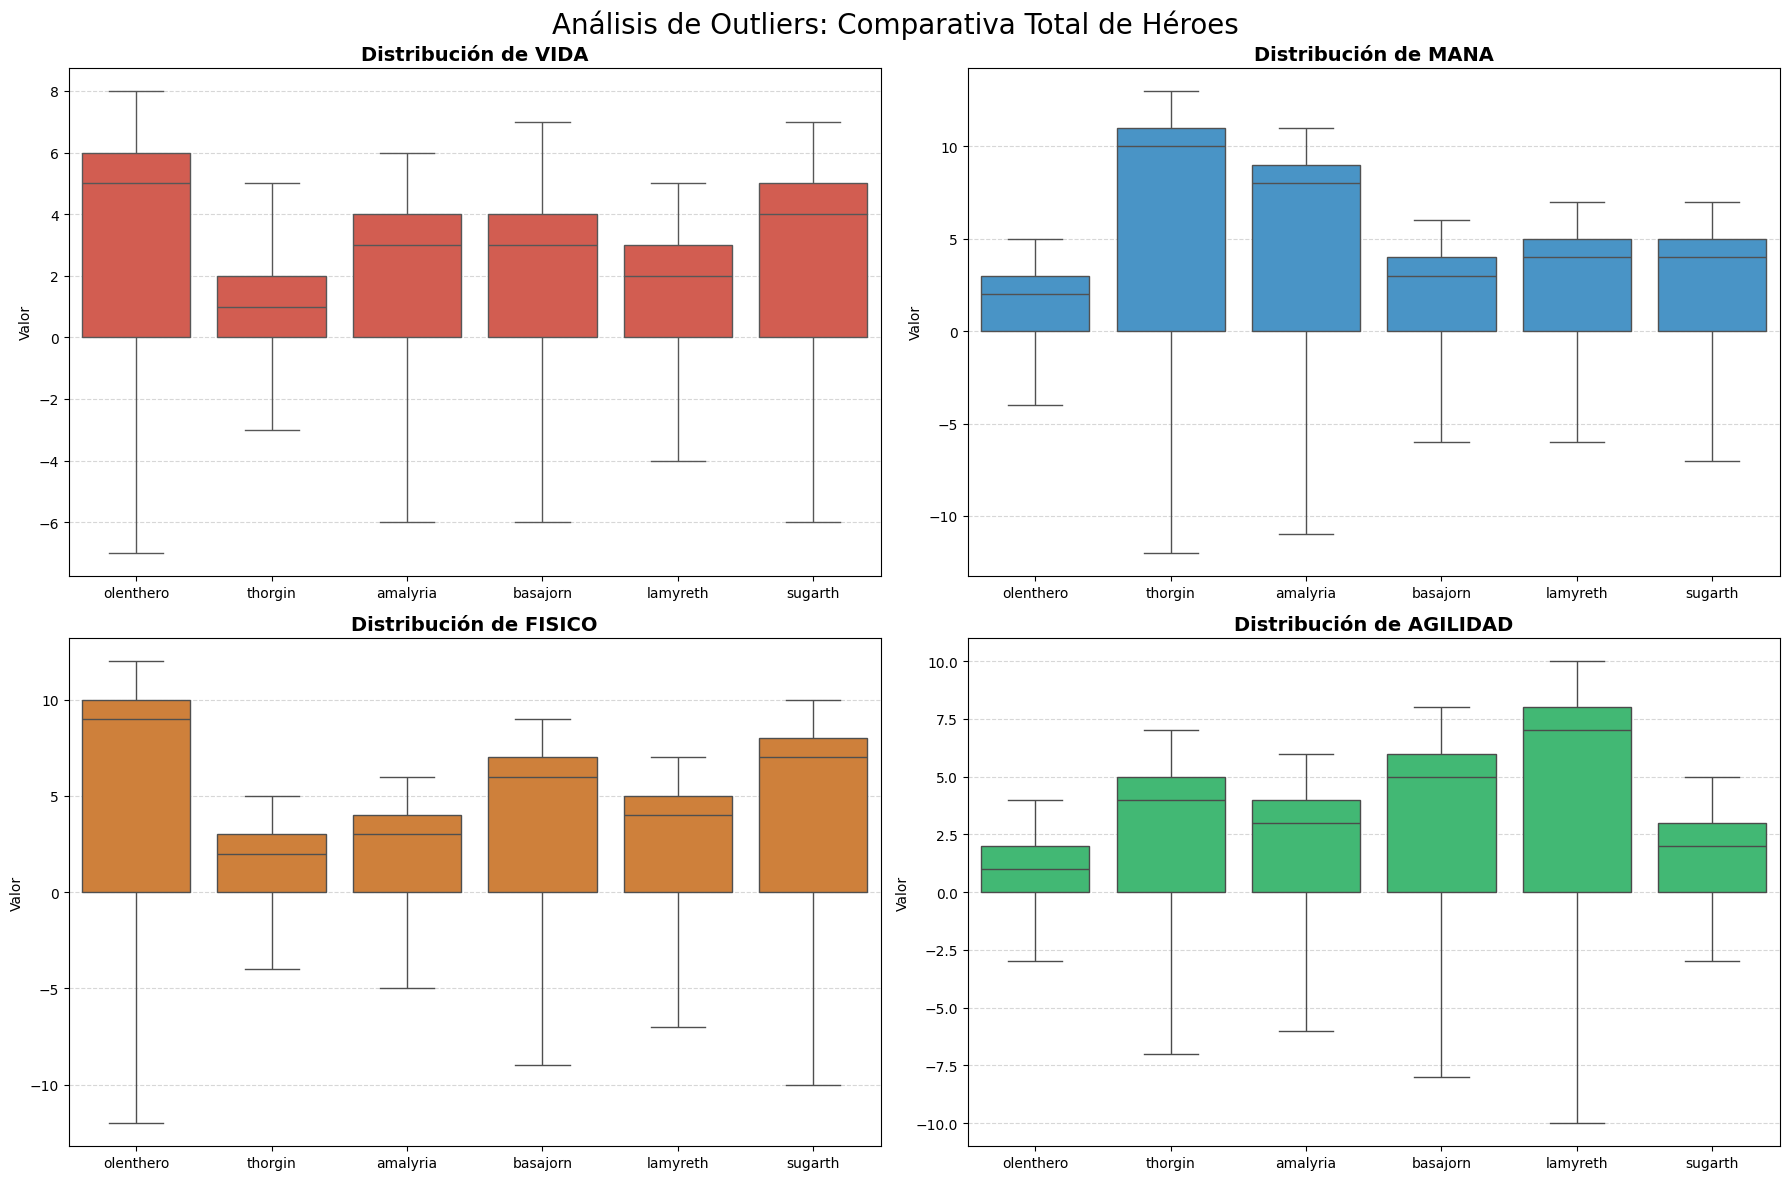

In [13]:
stats_types = ['vida', 'mana', 'fisico', 'agilidad']
cols_stats = [c for c in df.columns if any(c.endswith(f"_{s}") for s in stats_types)]

df_long = df[cols_stats].melt(var_name='columna_original', value_name='Valor')

df_long[['Heroe', 'Estadistica']] = df_long['columna_original'].str.rsplit('_', n=1, expand=True)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Análisis de Outliers: Comparativa Total de Héroes', fontsize=20)
palette_map = {'vida': '#e74c3c', 'mana': '#3498db', 'fisico': '#e67e22', 'agilidad': '#2ecc71'}

for i, stat in enumerate(stats_types):
    row, col = i // 2, i % 2
    ax = axes[row, col]

    subset = df_long[df_long['Estadistica'] == stat]

    sns.boxplot(data=subset, x='Heroe', y='Valor', ax=ax, color=palette_map[stat])

    ax.set_title(f'Distribución de {stat.upper()}', fontsize=14, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Valor')
    ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

**Más Limpieza y segmentación**

* Identificamos dinamicamente todas las columnas relacionadas con la presencia de heroes (las que terminan en "_en_equipo")

* Nos aseguramos que los datos sean númericos (convirtiendo nulos a 0) para evitar fallos.

* creamos una nueva variable "total_heroes" sumando horizontalmente todas las columnas seleccionadas

* Generamos un nuevo dataframe conservando unicamente las filas donde la suma de héroes es exactamente 4

In [14]:
columnas_heroes = [col for col in df.columns if col.endswith('_en_equipo')]

Usamos una lista de comprensión para escanear todas las columnas del DataFrame (df.columns) y filtramos solo las columnas que tiene ese sufijo (_en_equipo) en especifico.

In [15]:
for col in columnas_heroes:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)


Intenta convertir todo a números, si encuentra error o null lo convierte a NaN, luego toma ese NaN y los rellena con 0. Esto asume que si el dato está corrupto o vacío, el héroe no estba presente.

In [16]:
df['total_heroes'] = df[columnas_heroes].sum(axis=1)

 Calculamos el tamaño del equipo sumando las presencias (1.0 = Sí, 0.0 = No)

In [17]:
equipos_de_cuatro = df[df['total_heroes'] == 4].copy()

In [18]:
print(f"Total de incursiones registradas: {len(df)}")
print(f"Incursiones con exactamente 4 héroes: {len(equipos_de_cuatro)}")
print("\nPrimeros registros que cumplen la condición:")
print(equipos_de_cuatro[columnas_heroes + ['exito']].head())

Total de incursiones registradas: 835
Incursiones con exactamente 4 héroes: 385

Primeros registros que cumplen la condición:
   olenthero_en_equipo  thorgin_en_equipo  amalyria_en_equipo  \
0                  1.0                1.0                 0.0   
1                  1.0                1.0                 0.0   
2                  1.0                1.0                 0.0   
3                  1.0                1.0                 0.0   
6                  1.0                1.0                 1.0   

   basajorn_en_equipo  lamyreth_en_equipo  sugarth_en_equipo  exito  
0                 1.0                 1.0                0.0      0  
1                 1.0                 0.0                1.0      0  
2                 1.0                 0.0                1.0      1  
3                 1.0                 0.0                1.0      0  
6                 0.0                 0.0                1.0      0  


Diccionario de stats base

In [19]:
stats_base = {
    'olenthero': {'vida': 5, 'mana': 1, 'fisico': 8, 'agilidad': 1},
    'thorgin':   {'vida': 1, 'mana': 9, 'fisico': 1, 'agilidad': 4},
    'amalyria':  {'vida': 3, 'mana': 7, 'fisico': 2, 'agilidad': 3},
    'basajorn':  {'vida': 3, 'mana': 2, 'fisico': 5, 'agilidad': 5},
    'lamyreth':  {'vida': 2, 'mana': 3, 'fisico': 3, 'agilidad': 7},
    'sugarth':   {'vida': 4, 'mana': 3, 'fisico': 6, 'agilidad': 2},
}

Si un dato está corrupto, el script necesita saber cuáles son los valores mínimos (base) de cada héroe para poder reconstruirlo.

In [20]:
heroes = ['olenthero', 'thorgin', 'amalyria', 'basajorn', 'lamyreth', 'sugarth']

Este bloque implementa un algoritmo fila por fila para asegurar la coherencia de los datos de los héroes. No solo limpia, sino que repara la información basándose en las reglas del juego:

Detección Inteligente: Identifica si un héroe participó en la misión, ya sea por la columna _en_equipo o porque existen estadísticas registradas (aunque la bandera diga 0).

Validación de Reglas (Regla del 20): Verifica si la suma de los atributos (vida + mana + fisico + agilidad) es exactamente 20.

Si los datos son válidos (suman 20), se respetan los originales.

Si los datos están corruptos (suman mal) o faltan (son nulos), se regeneran partiendo de las estadísticas base del héroe + 5 puntos repartidos aleatoriamente.

Limpieza: Si el héroe no participó, se rellenan todos sus campos con 0.

In [21]:
def procesar_fila_completa(row):

    for heroe in heroes:
        col_equipo = f"{heroe}_en_equipo"
        col_vida = f"{heroe}_vida"
        col_mana = f"{heroe}_mana"
        col_fisico = f"{heroe}_fisico"
        col_agilidad = f"{heroe}_agilidad"

        cols_stats = [col_vida, col_mana, col_fisico, col_agilidad]

        flag_equipo = row[col_equipo] if pd.notnull(row[col_equipo]) else 0

        valores_actuales = [row[c] for c in cols_stats]
        suma_existente = np.nansum([v for v in valores_actuales if pd.notnull(v)])
        tiene_stats = suma_existente > 0

        if flag_equipo == 1 or tiene_stats:

            row[col_equipo] = 1.0

            hay_nulos = any(pd.isnull(row[c]) for c in cols_stats)

            suma_total = sum([row[c] if pd.notnull(row[c]) else 0 for c in cols_stats])
            suma_incorrecta = abs(suma_total - 20) > 0.1

            if hay_nulos or suma_incorrecta:

                base = stats_base[heroe]
                nuevos_stats = [base['vida'], base['mana'], base['fisico'], base['agilidad']]

                puntos = 5
                while puntos > 0:
                    idx = np.random.randint(0, 4)
                    nuevos_stats[idx] += 1
                    puntos -= 1

                row[col_vida] = nuevos_stats[0]
                row[col_mana] = nuevos_stats[1]
                row[col_fisico] = nuevos_stats[2]
                row[col_agilidad] = nuevos_stats[3]


        else:
            row[col_equipo] = 0.0
            for col in cols_stats:
                row[col] = 0.0

    return row

Preparación y ejecución de la función

In [22]:
cols_todas = []
for h in heroes:
    cols_todas.extend([f"{h}_en_equipo", f"{h}_vida", f"{h}_mana", f"{h}_fisico", f"{h}_agilidad"])

for col in cols_todas:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print("Procesando dataset y recuperando héroes...")
df_limpio = df.apply(procesar_fila_completa, axis=1)

print("\n" + "="*60)
print(f"{'HÉROE':<15} | {'EN EQUIPO (Total)':<20} | {'VALIDACIÓN (Suma=20)'}")
print("="*60)

for h in heroes:

    total_en_equipo = df_limpio[f"{h}_en_equipo"].sum()

    mask = df_limpio[f"{h}_en_equipo"] == 1
    if mask.sum() > 0:
        sumas = df_limpio[mask][[f"{h}_vida", f"{h}_mana", f"{h}_fisico", f"{h}_agilidad"]].sum(axis=1)
        todas_correctas = ((sumas - 20).abs() < 0.1).all()
        estado = "OK" if todas_correctas else "ERROR"
    else:
        estado = "N/A (Nadie en equipo)"

    print(f"{h.capitalize():<15} | {int(total_en_equipo):<20} | {estado}")

print("-" * 60)
total_nulos = df_limpio.isnull().sum().sum()
print(f"Total de celdas nulas en el dataset final: {total_nulos}")

Procesando dataset y recuperando héroes...

HÉROE           | EN EQUIPO (Total)    | VALIDACIÓN (Suma=20)
Olenthero       | 566                  | OK
Thorgin         | 563                  | OK
Amalyria        | 530                  | OK
Basajorn        | 577                  | OK
Lamyreth        | 563                  | OK
Sugarth         | 546                  | OK
------------------------------------------------------------
Total de celdas nulas en el dataset final: 0


Calcula cuántos héroes quedaron finalmente en equipos.

Verifica de nuevo si la columna "Estado" es "OK", asegurando que tras la limpieza nadie rompa la regla de sumar 20 puntos.

**Integridad de los equipos**

In [23]:
cols_equipo = [f"{h}_en_equipo" for h in heroes]

Definimos las columnas de equipo

In [24]:
df_limpio['total_heroes'] = df_limpio[cols_equipo].sum(axis=1)

Calculamos cuántos héroes hay en cada fila

In [25]:
print("--- REPORTE DE INTEGRIDAD DE EQUIPOS ---")
conteo = df_limpio['total_heroes'].value_counts().sort_index()
print(conteo)

print("\nDetalle:")
print(f"Filas CORRECTAS (4 héroes): {conteo.get(4, 0)}")
print(f"Filas INCORRECTAS (Distinto de 4): {len(df_limpio) - conteo.get(4, 0)}")

--- REPORTE DE INTEGRIDAD DE EQUIPOS ---
total_heroes
3.0     12
4.0    808
5.0     13
6.0      2
Name: count, dtype: int64

Detalle:
Filas CORRECTAS (4 héroes): 808
Filas INCORRECTAS (Distinto de 4): 27


Tras la limpieza vemos una tabla arriba que nos indica cuantos registros tienen mas de cuatro héroes en cada equipo o menos.

Sacamos las filas incorrectas que en total serian 27.

In [26]:
df_final = df_limpio[df_limpio['total_heroes'] == 4].copy()

In [27]:
borradas = len(df_limpio) - len(df_final)
print(f"Filas eliminadas (equipos incorrectos): {borradas}")
print(f"Filas finales en el dataset: {len(df_final)}")

Filas eliminadas (equipos incorrectos): 27
Filas finales en el dataset: 808


Decidimos borrrar los 27 registros (equipos incorrectos) ya que deben de ser si o si equipos formados por 4 heroes.

In [28]:
print("\nVerificación de integridad:")
check = df_final[cols_equipo].sum(axis=1).unique()
if len(check) == 1 and check[0] == 4:
    print("PERFECTO: Todas las filas restantes tienen exactamente 4 héroes.")
else:
    print("ALERTA: Algo salió mal, revisa el filtro.")


Verificación de integridad:
PERFECTO: Todas las filas restantes tienen exactamente 4 héroes.


In [29]:
df_final = df_final.drop(columns=['total_heroes'])

Eliminamos la columna auxiliar 'total_heroes' ya que no la necesitamos para nada

In [30]:
print("-" * 30)
print(f"Limpieza completada")
print(f"Archivo guardado como: {archivo_salida}")
print(f"Filas resultantes: {df_final.shape[0]}")
print(f"Nulos totales detectados: {df_final.isnull().sum().sum()}")
print("-" * 30)

------------------------------
Limpieza completada
Archivo guardado como: bosque_maldito_limpio.csv
Filas resultantes: 808
Nulos totales detectados: 0
------------------------------


Un resumen de que la limpieza ha sido completada y los nulos detectados tras la limpieza

In [31]:
df_final.to_csv(archivo_salida, index=False)